# LuxNLP NER Demo 

This notebook demonstrates the evaluation and analysis of the trained **LuxNLP Named Entity Recognition (NER)** model.

The following components are included:

- Dataset statistics for Train, Development, and Test splits  
- Model evaluation on Development and Test sets  
- Per-entity Precision, Recall, and F1-score visualization  
- Entity support distribution (pie chart)  
- Token-level confusion matrix (entity-type level)  
- Qualitative comparison: Gold vs Predicted examples  
- Interactive Luxembourgish sentence inference  

---

### Paths Used for Demonstration

- **Dataset:** `Demo/data/processed/Model_data/{train,dev,test}.conll`  
- **Model:** `Demo/model/Xlmr_Model`


In [1]:
# ===============================
# 1) Imports + Configuration
# ===============================

import re
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification

# --- Paths ---
DEMO_ROOT = Path(r"D:\DOWNLOADS\BRAVE\LuxNLP\Demo")
DATA_DIR  = DEMO_ROOT / "data" / "processed" / "Model_data"
MODEL_DIR = DEMO_ROOT / "model" / "Xlmr_Model"

TRAIN_PATH = DATA_DIR / "train.conll"
DEV_PATH   = DATA_DIR / "dev.conll"
TEST_PATH  = DATA_DIR / "test.conll"

MAX_LENGTH = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE:", DEVICE)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)

assert TRAIN_PATH.exists(), f"Missing: {TRAIN_PATH}"
assert DEV_PATH.exists(), f"Missing: {DEV_PATH}"
assert TEST_PATH.exists(), f"Missing: {TEST_PATH}"
assert MODEL_DIR.exists(), f"Missing: {MODEL_DIR}"

d:\DOWNLOADS\BRAVE\LuxNLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DEVICE: cpu
DATA_DIR: D:\DOWNLOADS\BRAVE\LuxNLP\Demo\data\processed\Model_data
MODEL_DIR: D:\DOWNLOADS\BRAVE\LuxNLP\Demo\model\Xlmr_Model


In [2]:
# ===============================
# 2) CoNLL Reading + BIO Helpers
# ===============================

def read_conll(path: Path):
    """Return list of sentences; each sentence is list[(token, tag)]."""
    sents, cur = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if cur:
                    sents.append(cur)
                    cur = []
                continue
            parts = line.split()
            tok = parts[0]
            tag = parts[-1]
            cur.append((tok, tag))
    if cur:
        sents.append(cur)
    return sents


def spans_from_bio(tags):
    """BIO -> list of (type, start, end_exclusive)."""
    spans = []
    i = 0
    while i < len(tags):
        tag = tags[i]
        if tag.startswith("B-"):
            typ = tag[2:]
            j = i + 1
            while j < len(tags) and tags[j] == f"I-{typ}":
                j += 1
            spans.append((typ, i, j))
            i = j
        else:
            i += 1
    return spans


def clean_type(tag):
    """B-PER/I-PER -> PER ; O -> O"""
    return tag.split("-", 1)[1] if "-" in tag else tag

In [3]:
# ===============================
# 3) Dataset Statistics (like conll_stats)
# ===============================

def dataset_stats(path: Path):
    sents = read_conll(path)
    n_sents = len(sents)
    n_tokens = sum(len(s) for s in sents)

    tag_counts = Counter()
    span_counts = Counter()
    type_token_counts = Counter()
    unique_entities = defaultdict(set)

    for sent in sents:
        tokens = [t for t, _ in sent]
        tags = [y for _, y in sent]
        for y in tags:
            tag_counts[y] += 1
            if y.startswith(("B-", "I-")):
                type_token_counts[y.split("-", 1)[1]] += 1

        for typ, s, e in spans_from_bio(tags):
            span_counts[typ] += 1
            unique_entities[typ].add(" ".join(tokens[s:e]))

    o = tag_counts.get("O", 0)
    ent = n_tokens - o
    label_types = sorted({t.split("-", 1)[1] for t in tag_counts if t.startswith(("B-", "I-"))})

    return {
        "file": str(path),
        "sentences": n_sents,
        "tokens": n_tokens,
        "o_tokens": o,
        "ent_tokens": ent,
        "o_ratio": (o / n_tokens) if n_tokens else 0.0,
        "ent_ratio": (ent / n_tokens) if n_tokens else 0.0,
        "label_types": label_types,
        "span_counts": dict(span_counts),
        "unique_entities": {k: len(v) for k, v in unique_entities.items()},
        "type_token_counts": dict(type_token_counts),
        "top_tags": tag_counts.most_common(15)
    }


def print_stats(name, st):
    print(f"\n=== {name} ===")
    print("File:", st["file"])
    print("Sentences:", st["sentences"])
    print("Tokens   :", st["tokens"])
    print("Labels   :", st["label_types"])
    print(f"O tokens : {st['o_tokens']} ({st['o_ratio']:.2%})")
    print(f"ENT tok. : {st['ent_tokens']} ({st['ent_ratio']:.2%})")

    print("\nPer-type spans / unique entities / entity-token-count:")
    for typ in sorted(st["span_counts"].keys()):
        spans = st["span_counts"].get(typ, 0)
        uniq = st["unique_entities"].get(typ, 0)
        tokc = st["type_token_counts"].get(typ, 0)
        print(f"  {typ:<10} spans={spans:>6} | unique={uniq:>6} | ent_tokens={tokc:>7}")

    print("\nTop tags:")
    for t, c in st["top_tags"]:
        print(f"  {t:<10} {c}")


train_st = dataset_stats(TRAIN_PATH)
dev_st   = dataset_stats(DEV_PATH)
test_st  = dataset_stats(TEST_PATH)

print_stats("TRAIN", train_st)
print_stats("DEV", dev_st)
print_stats("TEST", test_st)



=== TRAIN ===
File: D:\DOWNLOADS\BRAVE\LuxNLP\Demo\data\processed\Model_data\train.conll
Sentences: 26096
Tokens   : 308734
Labels   : ['DATE', 'EVENT', 'LOC', 'MED', 'ORG', 'PER', 'PRODUCT']
O tokens : 237168 (76.82%)
ENT tok. : 71566 (23.18%)

Per-type spans / unique entities / entity-token-count:
  DATE       spans=  5949 | unique=  4423 | ent_tokens=  17718
  EVENT      spans=  5518 | unique=  2853 | ent_tokens=  11061
  LOC        spans= 12359 | unique=  1008 | ent_tokens=  13695
  MED        spans=  4503 | unique=   436 | ent_tokens=   4566
  ORG        spans=  4051 | unique=   251 | ent_tokens=   8328
  PER        spans=  5309 | unique=   749 | ent_tokens=  11720
  PRODUCT    spans=  4228 | unique=   920 | ent_tokens=   4478

Top tags:
  O          237168
  B-LOC      12359
  I-DATE     11769
  I-PER      6411
  B-DATE     5949
  I-EVENT    5543
  B-EVENT    5518
  B-PER      5309
  B-MED      4503
  I-ORG      4277
  B-PRODUCT  4228
  B-ORG      4051
  I-LOC      1336
  I-PROD

In [4]:
# ===============================
# 4) Load the Model
# ===============================

tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
model.eval()

id2label = model.config.id2label
label2id = model.config.label2id
labels = [id2label[i] for i in range(len(id2label))]
print("Loaded labels:", labels)

The tokenizer you are loading from 'D:\DOWNLOADS\BRAVE\LuxNLP\Demo\model\Xlmr_Model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Loaded labels: ['O', 'B-DATE', 'B-EVENT', 'B-LOC', 'B-MED', 'B-MEDICINE', 'B-ORG', 'B-PER', 'B-PRODUCT', 'I-DATE', 'I-EVENT', 'I-LOC', 'I-MED', 'I-MEDICINE', 'I-ORG', 'I-PER', 'I-PRODUCT']


In [5]:
# ===============================
# 5) Prediction aligned to words
# ===============================

@torch.no_grad()
def predict_tags_word_aligned(tokens, max_length=256):
    enc = tokenizer(
        tokens,
        is_split_into_words=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    logits = model(**enc).logits[0]
    pred_ids = torch.argmax(logits, dim=-1).detach().cpu().tolist()

    word_ids = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=max_length).word_ids()
    out = []
    seen = set()
    for idx, wid in enumerate(word_ids):
        if wid is None or wid in seen:
            continue
        seen.add(wid)
        out.append(id2label[int(pred_ids[idx])])
    return out


def compute_span_metrics(gold_pairs, pred_tags_list):
    tp = defaultdict(int)
    fp = defaultdict(int)
    fn = defaultdict(int)
    support_gold = defaultdict(int)
    all_types = set()

    for (tokens, gold_tags), pred_tags in zip(gold_pairs, pred_tags_list):
        n = min(len(tokens), len(gold_tags), len(pred_tags))
        gold_tags = gold_tags[:n]
        pred_tags = pred_tags[:n]

        gold_spans = set(spans_from_bio(gold_tags))
        pred_spans = set(spans_from_bio(pred_tags))

        for typ, _, _ in gold_spans:
            support_gold[typ] += 1
            all_types.add(typ)
        for typ, _, _ in pred_spans:
            all_types.add(typ)

        for span in (gold_spans & pred_spans):
            tp[span[0]] += 1
        for span in (pred_spans - gold_spans):
            fp[span[0]] += 1
        for span in (gold_spans - pred_spans):
            fn[span[0]] += 1

    per_type = {}
    for typ in sorted(all_types):
        tpi, fpi, fni = tp[typ], fp[typ], fn[typ]
        p = tpi / (tpi + fpi) if (tpi + fpi) else 0.0
        r = tpi / (tpi + fni) if (tpi + fni) else 0.0
        f1 = (2*p*r/(p+r)) if (p+r) else 0.0
        per_type[typ] = {
            "tp": tpi, "fp": fpi, "fn": fni,
            "precision": p, "recall": r, "f1": f1,
            "support_gold": support_gold[typ]
        }

    TP = sum(tp.values())
    FP = sum(fp.values())
    FN = sum(fn.values())
    micro_p = TP / (TP + FP) if (TP + FP) else 0.0
    micro_r = TP / (TP + FN) if (TP + FN) else 0.0
    micro_f1 = (2*micro_p*micro_r/(micro_p+micro_r)) if (micro_p+micro_r) else 0.0

    supported = [t for t in per_type if per_type[t]["support_gold"] > 0]
    macro_f1 = float(np.mean([per_type[t]["f1"] for t in supported])) if supported else 0.0

    overall = {
        "micro_precision": micro_p,
        "micro_recall": micro_r,
        "micro_f1": micro_f1,
        "macro_f1": macro_f1,
        "types_with_support": len(supported)
    }

    return per_type, overall


def eval_conll(conll_path: Path):
    sents = read_conll(conll_path)
    gold_pairs = [([t for t, _ in sent], [y for _, y in sent]) for sent in sents]
    pred_tags_list = []
    for tokens, _ in gold_pairs:
        pred_tags_list.append(predict_tags_word_aligned(tokens, max_length=MAX_LENGTH))

    per_type, overall = compute_span_metrics(gold_pairs, pred_tags_list)
    df = pd.DataFrame([{"type": t, **vals} for t, vals in per_type.items()])
    df = df[df["support_gold"] > 0].sort_values("type")
    return df, overall, gold_pairs, pred_tags_list


In [6]:
# ===============================
# 6) Evaluate DEV and TEST 
# ===============================

FORCE_REEVAL = False 

if (not FORCE_REEVAL) and all(k in globals() for k in ["df_dev","df_test","overall_dev","overall_test","gold_dev","pred_dev","gold_test","pred_test"]):
    print("Using cached evaluation results (set FORCE_REEVAL=True to recompute).")
else:
    df_dev, overall_dev, gold_dev, pred_dev = eval_conll(DEV_PATH)
    df_test, overall_test, gold_test, pred_test = eval_conll(TEST_PATH)




In [7]:
EXCLUDE_TYPES = {"MEDICINE"}   

df_dev = df_dev[~df_dev["type"].isin(EXCLUDE_TYPES)].reset_index(drop=True)
df_test = df_test[~df_test["type"].isin(EXCLUDE_TYPES)].reset_index(drop=True)



In [8]:

print("DEV overall:", overall_dev)
print("TEST overall:", overall_test)

display(df_dev)
display(df_test)

DEV overall: {'micro_precision': 0.8810983084089238, 'micro_recall': 0.8284923928077456, 'micro_f1': 0.8539859807532375, 'macro_f1': 0.7094884666229428, 'types_with_support': 8}
TEST overall: {'micro_precision': 0.7741854003536246, 'micro_recall': 0.7493887530562348, 'micro_f1': 0.7615852900981488, 'macro_f1': 0.6249804469737499, 'types_with_support': 8}


,type,tp,fp,fn,precision,recall,f1,support_gold
0,DATE,651,0,0,1.000000,1.000000,1.000000,651
1,EVENT,420,22,46,0.950226,0.901288,0.925110,466
2,LOC,1159,13,241,0.988908,0.827857,0.901244,1400
3,MED,267,258,69,0.508571,0.794643,0.620209,336
4,ORG,339,11,243,0.968571,0.582474,0.727468,582
5,PER,622,87,47,0.877292,0.929746,0.902758,669
6,PRODUCT,136,94,88,0.591304,0.607143,0.599119,224


,type,tp,fp,fn,precision,recall,f1,support_gold
0,DATE,521,90,100,0.852700,0.838969,0.845779,621
1,EVENT,324,59,76,0.845953,0.810000,0.827586,400
2,LOC,1104,32,197,0.971831,0.848578,0.906032,1301
3,MED,276,301,76,0.478336,0.784091,0.594187,352
4,ORG,333,27,213,0.925000,0.609890,0.735099,546
5,PER,395,251,230,0.611455,0.632000,0.621558,625
6,PRODUCT,112,134,119,0.455285,0.484848,0.469602,231


In [9]:
# ===============================
# 7) Plots (clean + nicer)
# ===============================

EXCLUDE_TYPES = {"MEDICINE"}  
DROP_ZERO_SUPPORT = True      

def filter_entity_df(df, exclude_types=EXCLUDE_TYPES, drop_zero_support=DROP_ZERO_SUPPORT):
    d = df.copy()
    if exclude_types:
        d = d[~d["type"].isin(list(exclude_types))]
    if drop_zero_support and "support_gold" in d.columns:
        d = d[d["support_gold"] > 0]
    return d.reset_index(drop=True)

df_test_plot = filter_entity_df(df_test)
df_dev_plot  = filter_entity_df(df_dev)

In [10]:


def plot_prf_bar(df, title):
    plt.figure(figsize=(10, 5))
    x = np.arange(len(df))
    w = 0.25
    plt.bar(x - w, df["precision"], width=w, label="Precision")
    plt.bar(x,     df["recall"],    width=w, label="Recall")
    plt.bar(x + w, df["f1"],        width=w, label="F1")
    plt.ylim(0, 1)
    plt.xticks(x, df["type"], rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_f1_bar(df, title):
    plt.figure(figsize=(10, 5))
    plt.bar(df["type"], df["f1"])
    plt.ylim(0, 1)
    plt.ylabel("F1")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_support_pie(df, title):
    plt.figure(figsize=(7, 7))
    sizes = df["support_gold"].values
    labels = df["type"].tolist()
    if sizes.sum() == 0:
        plt.text(0.5, 0.5, "No gold spans", ha="center", va="center")
        plt.axis("off")
    else:
        plt.pie(sizes, labels=labels, autopct="%1.1f%%")
    plt.title(title)
    plt.tight_layout()
    plt.show()


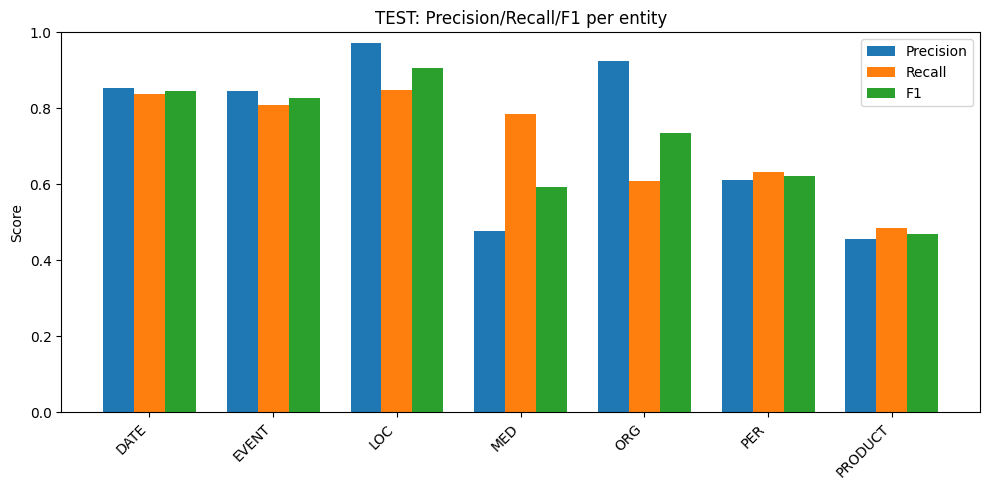

In [11]:
plot_prf_bar(df_test_plot, 'TEST: Precision/Recall/F1 per entity')


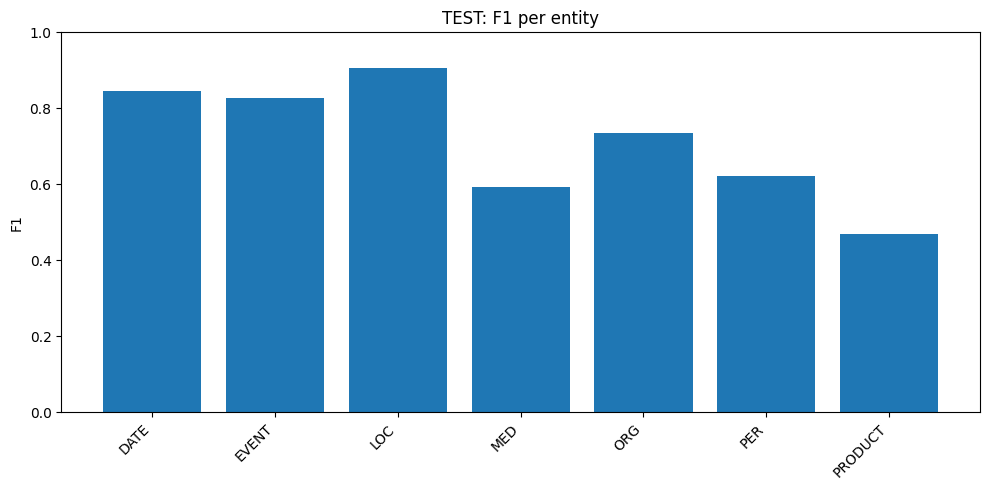

In [12]:
plot_f1_bar(df_test_plot, 'TEST: F1 per entity')


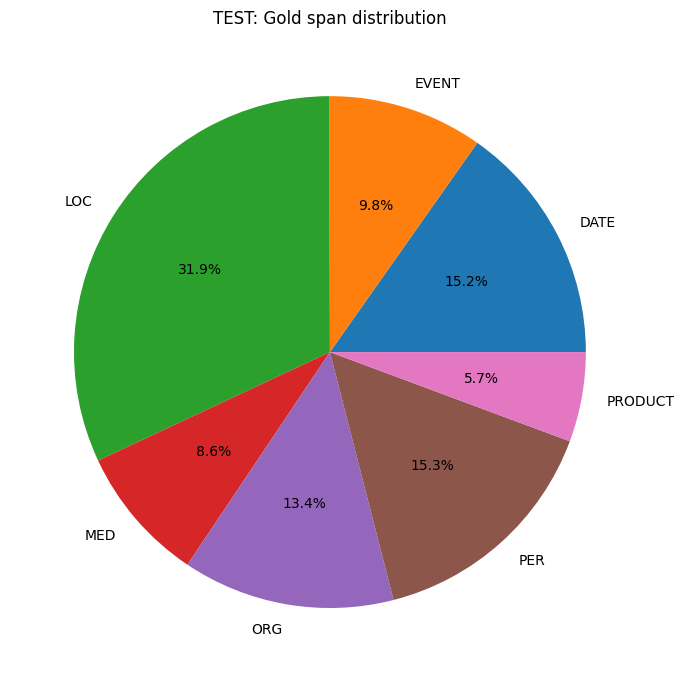

In [13]:
plot_support_pie(df_test_plot, 'TEST: Gold span distribution')


In [14]:
# ===============================
# 8) Confusion Matrix (token-level, entity types)
# ===============================

def token_confusion_matrix(gold_pairs, pred_tags_list, exclude_types=EXCLUDE_TYPES):
    y_true, y_pred = [], []
    for (tokens, gold_tags), pred_tags in zip(gold_pairs, pred_tags_list):
        n = min(len(gold_tags), len(pred_tags))
        g = gold_tags[:n]
        p = pred_tags[:n]
        y_true.extend([clean_type(x) for x in g])
        y_pred.extend([clean_type(x) for x in p])

    labels = sorted(list(set(y_true) | set(y_pred)))
    if exclude_types:
        labels = [l for l in labels if l not in exclude_types]

    cm = pd.crosstab(pd.Series(y_true, name="Gold"), pd.Series(y_pred, name="Pred"))
    cm = cm.reindex(index=labels, columns=labels, fill_value=0)
    return cm

def plot_confusion_matrix(cm, title="Confusion Matrix (Token-level)"):
    import numpy as _np

    data = cm.values.astype(float)
    if data.size == 0:
        print("Empty confusion matrix.")
        return


    vmax = _np.percentile(data, 95) if _np.any(data) else 1.0
    vmax = max(vmax, 1.0)

    plt.figure(figsize=(10, 8))
    im = plt.imshow(data, aspect="auto", interpolation="nearest", cmap="Blues", vmin=0, vmax=vmax)
    plt.title(title)
    plt.xticks(range(len(cm.columns)), cm.columns, rotation=45, ha="right")
    plt.yticks(range(len(cm.index)), cm.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)


    thresh = vmax * 0.5
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = int(data[i, j])
            if val == 0:
                continue
            plt.text(j, i, str(val),
                     ha="center", va="center",
                     fontsize=9,
                     color=("white" if data[i, j] > thresh else "black"))

    plt.tight_layout()
    plt.show()


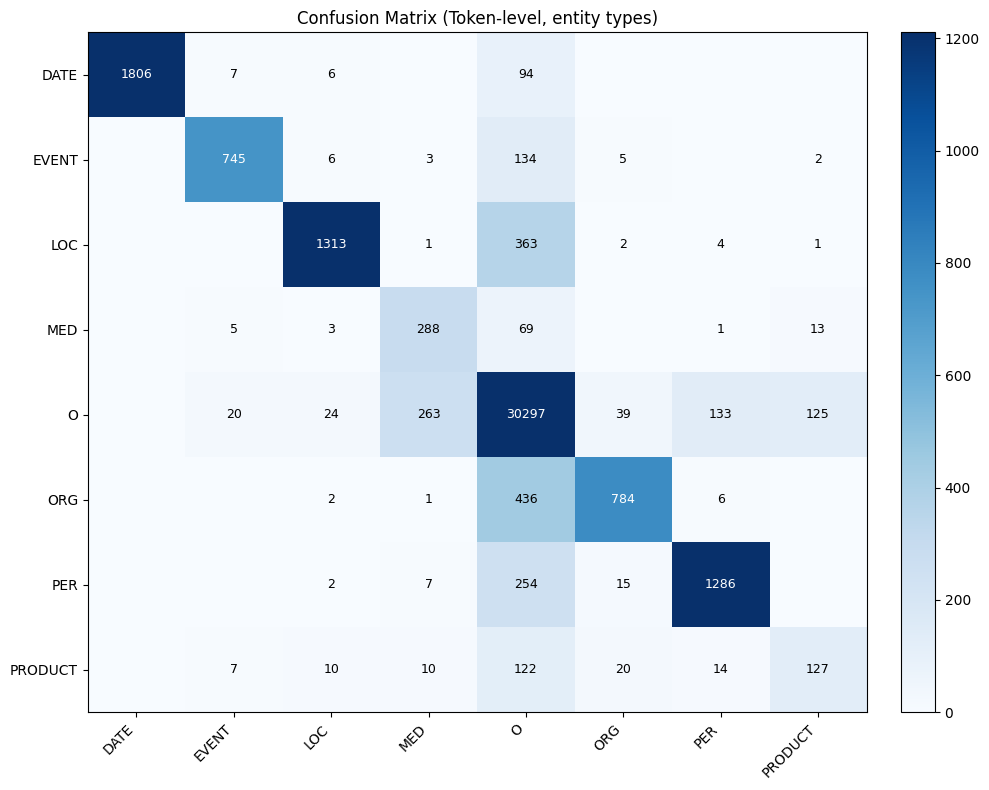

Pred,DATE,EVENT,LOC,MED,O,ORG,PER,PRODUCT
Gold,,,,,,,,
DATE,1806,7,6,0,94,0,0,0
EVENT,0,745,6,3,134,5,0,2
LOC,0,0,1313,1,363,2,4,1
MED,0,5,3,288,69,0,1,13
O,0,20,24,263,30297,39,133,125
ORG,0,0,2,1,436,784,6,0
PER,0,0,2,7,254,15,1286,0
PRODUCT,0,7,10,10,122,20,14,127


In [15]:
cm_test = token_confusion_matrix(gold_test, pred_test)
plot_confusion_matrix(cm_test, "Confusion Matrix (Token-level, entity types)")

display(cm_test)


In [16]:
# ===============================
# 9) Qualitative examples: 2–3 examples for EACH entity type
# ===============================

def find_examples_by_type(gold_pairs, pred_tags_list, entity_type, n_examples=3):
    examples = []
    for idx, ((tokens, gold_tags), pred_tags) in enumerate(zip(gold_pairs, pred_tags_list)):
        gold_spans = spans_from_bio(gold_tags)
        if any(t == entity_type for (t, s, e) in gold_spans):
            # keep a few
            examples.append((tokens, gold_tags, pred_tags))
            if len(examples) >= n_examples:
                break
    return examples


def show_example(tokens, gold_tags, pred_tags, max_tokens=80):
    n = min(len(tokens), len(gold_tags), len(pred_tags), max_tokens)
    df = pd.DataFrame({
        "token": tokens[:n],
        "gold": gold_tags[:n],
        "pred": pred_tags[:n],
    })
    return df


entity_types = sorted({t for row in df_test['type'].tolist() for t in [row]})
print("Entity types found in TEST:", entity_types)

for et in entity_types:
    print("\n" + "="*80)
    print(f"Examples for entity: {et}")
    exs = find_examples_by_type(gold_test, pred_test, et, n_examples=3)
    if not exs:
        print("No examples found.")
        continue
    for i, (tokens, g, p) in enumerate(exs, 1):
        print(f"\n--- Example {i} ---")
        display(show_example(tokens, g, p))

Entity types found in TEST: ['DATE', 'EVENT', 'LOC', 'MED', 'ORG', 'PER', 'PRODUCT']

Examples for entity: DATE

--- Example 1 ---


,token,gold,pred
0,Den,O,O
1,14.,B-DATE,B-DATE
2,Juni,I-DATE,I-DATE
3,2008,I-DATE,I-DATE
4,war,O,O
5,d'Evenement,O,O
6,zu,O,O
7,Esch,B-LOC,B-LOC
8,.,O,O



--- Example 2 ---


,token,gold,pred
0,Zu,O,O
1,Clierf,B-LOC,B-LOC
2,ass,O,O
3,Clierf,B-EVENT,B-EVENT
4,Nationalfeierdag,I-EVENT,I-EVENT
5,1996,I-EVENT,I-EVENT
6,den,O,O
7,14.,B-DATE,B-DATE
8,Juli,I-DATE,I-DATE
9,2006,I-DATE,I-DATE



--- Example 3 ---


...

,token,gold,pred
0,Zu,O,O
1,Remich,O,O
2,hunn,O,O
3,ech,O,O
4,Rappzalot,B-PRODUCT,B-PRODUCT
5,kaaft,O,O
6,.,O,O



--- Example 2 ---


,token,gold,pred
0,Ech,O,O
1,hunn,O,O
2,eng,O,O
3,Jeans,B-PRODUCT,B-PRODUCT
4,",",O,O
5,dei,O,O
6,ech,O,O
7,ganz,O,O
8,gären,O,O
9,droen,O,O



--- Example 3 ---


,token,gold,pred
0,Haut,O,O
1,benotzen,O,O
2,ech,O,O
3,Gingembre,B-PRODUCT,B-PRODUCT
4,all,O,O
5,Dag,O,O
6,.,O,O


In [17]:
# ===============================
# 10) Batch sentence tests (predefined)
#     Runs multiple Luxembourgish sentences and shows predicted entities.
# ===============================

def decode_spans(tokens, tags):
    spans = spans_from_bio(tags)
    out = []
    for typ, s, e in spans:
        out.append({
            "type": typ,
            "text": " ".join(tokens[s:e]),
            "start": s,
            "end": e,
        })
    return out


def predict_text(text: str):
    # Simple whitespace tokenization for demo
    tokens = text.strip().split()
    if not tokens:
        return [], [], []
    tags = predict_tags_word_aligned(tokens, max_length=MAX_LENGTH)
    n = min(len(tokens), len(tags))
    tokens = tokens[:n]
    tags = tags[:n]
    spans = decode_spans(tokens, tags)
    return tokens, tags, spans


# Test sentences 
tests = [
    "Den 12. Mee 2024 war d'Nationalfeierdag zu Lëtzebuerg.",
    "Ech schaffen bei Luxembourg Air Rescue zu Sandweiler.",
    "Jean-Claude Juncker war Premierminister vu Lëtzebuerg.",
    "E Concert ass den 15. August 2026 zu Esch.",
]

rows = []
for t in tests:
    tokens, tags, spans = predict_text(t)
    rows.append({
        "text": t,
        "predicted_spans": spans,
    })

display(pd.DataFrame(rows))

# Show token-level tags for the last sentence
if tests:
    t = tests[-1]
    tokens, tags, spans = predict_text(t)
    print("\nLast test (token-level):", t)
    display(pd.DataFrame({"token": tokens, "pred": tags}))
    print("Extracted spans:")
    display(pd.DataFrame(spans))


,text,predicted_spans
0,Den 12. Mee 2024 war d'Nationalfeierdag zu Lët...,"[{'type': 'DATE', 'text': '12. Mee 2024', 'sta..."
1,Ech schaffen bei Luxembourg Air Rescue zu Sand...,"[{'type': 'ORG', 'text': 'Luxembourg Air Rescu..."
2,Jean-Claude Juncker war Premierminister vu Lët...,"[{'type': 'PER', 'text': 'Jean-Claude Juncker'..."
3,E Concert ass den 15. August 2026 zu Esch.,"[{'type': 'EVENT', 'text': 'Concert', 'start':..."



Last test (token-level): E Concert ass den 15. August 2026 zu Esch.


,token,pred
0,E,O
1,Concert,B-EVENT
2,ass,O
3,den,O
4,15.,B-DATE
5,August,I-DATE
6,2026,I-DATE
7,zu,O
8,Esch.,B-LOC


Extracted spans:


,type,text,start,end
0,EVENT,Concert,1,2
1,DATE,15. August 2026,4,7
2,LOC,Esch.,8,9


In [18]:
# ===============================
# 11) Interactive demo: type a Luxembourgish sentence
# ===============================

user_text = input("Type a Luxembourgish sentence: ")
print("\nEntered Sentence:")
print(user_text)

tokens, tags, spans = predict_text(user_text)

print("\nToken-level prediction:")
display(pd.DataFrame({"token": tokens, "pred": tags}))

print("\nExtracted entity spans:")
display(pd.DataFrame(spans))



Entered Sentence:
Den Esch Festival fënnt de 5. Oktober 2024 zu Esch statt.

Token-level prediction:


,token,pred
0,Den,O
1,Esch,B-EVENT
2,Festival,I-EVENT
3,fënnt,O
4,de,O
5,5.,B-DATE
6,Oktober,I-DATE
7,2024,I-DATE
8,zu,O
9,Esch,B-LOC



Extracted entity spans:


,type,text,start,end
0,EVENT,Esch Festival,1,3
1,DATE,5. Oktober 2024,5,8
2,LOC,Esch,9,10


In [19]:
# ===============================
# 11) Interactive demo: continuous Luxembourgish inference loop
# ===============================

print("Interactive LuxNLP NER Demo")
print("Type a Luxembourgish sentence and press Enter.")
print("Type 'stop' (or 'exit' / 'quit') to end.\n")

while True:
    user_text = input("Type a Luxembourgish sentence: ").strip()

    # stop conditions
    if user_text == "" or user_text.lower() in {"stop", "exit", "quit"}:
        print("\nStopping interactive demo.")
        break

    print("\nEntered Sentence:")
    print(user_text)

    tokens, tags, spans = predict_text(user_text)

    print("\nToken-level prediction:")
    display(pd.DataFrame({"token": tokens, "pred": tags}))

    print("\nExtracted entity spans:")
    display(pd.DataFrame(spans))

    print("\n" + "-"*60 + "\n")


Interactive LuxNLP NER Demo
Type a Luxembourgish sentence and press Enter.
Type 'stop' (or 'exit' / 'quit') to end.


Entered Sentence:
Den Esch Festival fënnt de 5. Oktober 2024 zu Esch statt.

Token-level prediction:


,token,pred
0,Den,O
1,Esch,B-EVENT
2,Festival,I-EVENT
3,fënnt,O
4,de,O
5,5.,B-DATE
6,Oktober,I-DATE
7,2024,I-DATE
8,zu,O
9,Esch,B-LOC



Extracted entity spans:


,type,text,start,end
0,EVENT,Esch Festival,1,3
1,DATE,5. Oktober 2024,5,8
2,LOC,Esch,9,10



------------------------------------------------------------


Entered Sentence:
D'Anna Weber huet den 12. Mee 2024 Paracetamol geholl.

Token-level prediction:


...


------------------------------------------------------------


Entered Sentence:
De Tom Becker huet Aspirin am Centre Médical zu Esch kaaft.

Token-level prediction:


,token,pred
0,De,O
1,Tom,B-PER
2,Becker,I-PER
3,huet,O
4,Aspirin,O
5,am,O
6,Centre,O
7,Médical,I-ORG
8,zu,O
9,Esch,B-LOC



Extracted entity spans:


,type,text,start,end
0,PER,Tom Becker,1,3
1,LOC,Esch,9,10



------------------------------------------------------------


Stopping interactive demo.
